In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [74]:
sns.set_theme(style='whitegrid')

In [72]:
data = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [82]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
mean = data['TotalCharges'].mean()
data.fillna({'TotalCharges': mean}, inplace=True)
data['TotalCharges'].isna().sum()

np.int64(0)

In [84]:
data['TotalCharges'].describe()

count    7043.000000
mean     2283.300441
std      2265.000258
min        18.800000
25%       402.225000
50%      1400.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [ ]:
data['SeniorCitizen'] = data['SeniorCitizen'].map({0:'No', 1:'Yes'}).value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

In [ ]:
data = data.drop(columns=['customerID'])

In [93]:
data['Churn_flag'] = (data['Churn'] == 'Yes').astype(int)

In [94]:
print(data.shape)
print(data['Churn'].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


### Now the chi-square part. The idea: for each categorical feature we build a contingency table against Churn, run the test, and rank features by how strongly they associate with churn. I add Cramér’s V because chi-square’s statistic and p-value don’t tell you effect size, and with ~7000 rows almost everything comes back “significant.”

In [95]:
def cramers_v(confusion_matrix):
    """
    Effect size for chi-square 0 = no association, 1 = perfect.
    """
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    # bias correction (Bergsma)
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


In [96]:
cat_cols = data.select_dtypes(include=['object', 'str']).columns.drop('Churn')
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [111]:
results = []
for col in cat_cols:
    contingency = pd.crosstab(data[col], data["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    results.append({
        "feature": col,
        "chi2": chi2,
        "p_value": f'{p:.5f}',
        "dof": dof,
        "cramers_v": cramers_v(contingency),
    })

In [112]:
chi2_results = (
    pd.DataFrame(results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
print(chi2_results)

             feature         chi2  p_value  dof  cramers_v
0           Contract  1184.596572  0.00000    2   0.409798
1     OnlineSecurity   849.998968  0.00000    2   0.347016
2        TechSupport   828.197068  0.00000    2   0.342526
3    InternetService   732.309590  0.00000    2   0.322037
4      PaymentMethod   648.142327  0.00000    3   0.302677
5       OnlineBackup   601.812790  0.00000    2   0.291850
6   DeviceProtection   558.419369  0.00000    2   0.281095
7    StreamingMovies   375.661479  0.00000    2   0.230351
8        StreamingTV   374.203943  0.00000    2   0.229902
9   PaperlessBilling   258.277649  0.00000    1   0.191141
10        Dependents   189.129249  0.00000    1   0.163448
11           Partner   158.733382  0.00000    1   0.149663
12     MultipleLines    11.330441  0.00346    2   0.036400
13            gender     0.484083  0.48658    1   0.000000
14      PhoneService     0.915033  0.33878    1   0.000000


## Visualization

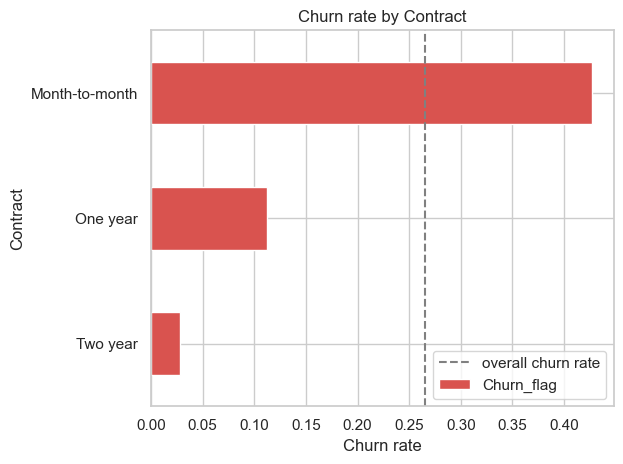

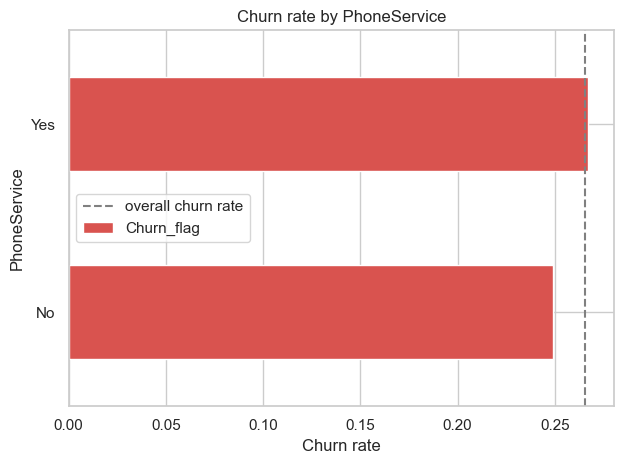

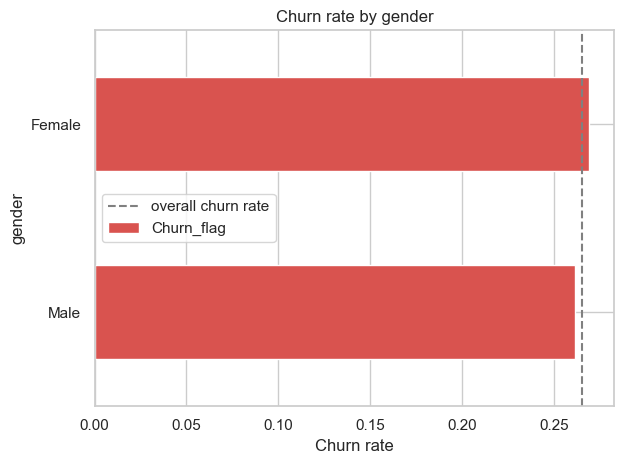

In [102]:
# 1. Churn rate per category (the workhorse plot)
def churn_rate_plot(col):
    rates = data.groupby(col)["Churn_flag"].mean().sort_values()
    ax = rates.plot(kind="barh", color="#d9534f")
    ax.axvline(data["Churn_flag"].mean(), ls="--", color="gray",
               label="overall churn rate")
    ax.set_xlabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

for col in ["Contract", "PhoneService", "gender"]:
    churn_rate_plot(col)


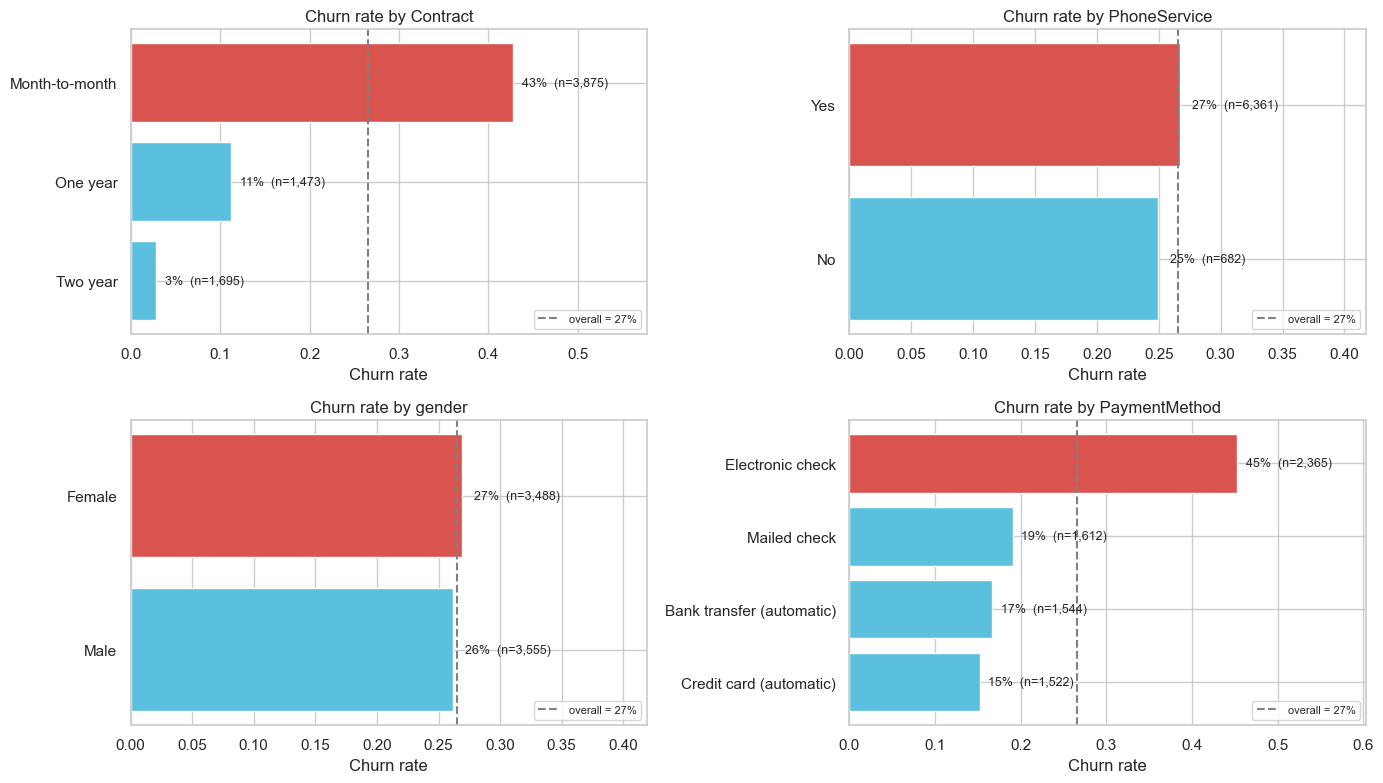

In [113]:
import matplotlib.pyplot as plt
import numpy as np

def churn_rate_panel(cols, ncols=2):
    overall = data["Churn_flag"].mean()
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, cols):
        g = data.groupby(col)["Churn_flag"].agg(["mean", "size"])
        g = g.sort_values("mean")

        # color each bar relative to the overall rate
        colors = ["#d9534f" if m >= overall else "#5bc0de" for m in g["mean"]]
        bars = ax.barh(g.index.astype(str), g["mean"], color=colors)

        ax.axvline(overall, ls="--", color="gray", lw=1.5,
                   label=f"overall = {overall:.0%}")

        # annotate rate + group size on each bar
        for bar, (m, n) in zip(bars, g[["mean", "size"]].to_numpy()):
            ax.text(m + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{m:.0%}  (n={int(n):,})",
                    va="center", fontsize=9)

        ax.set_xlim(0, min(1, g["mean"].max() + 0.15))
        ax.set_xlabel("Churn rate")
        ax.set_title(f"Churn rate by {col}")
        ax.legend(loc="lower right", fontsize=8)

    # hide any unused subplots
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

churn_rate_panel(["Contract", "PhoneService", "gender", "PaymentMethod"])


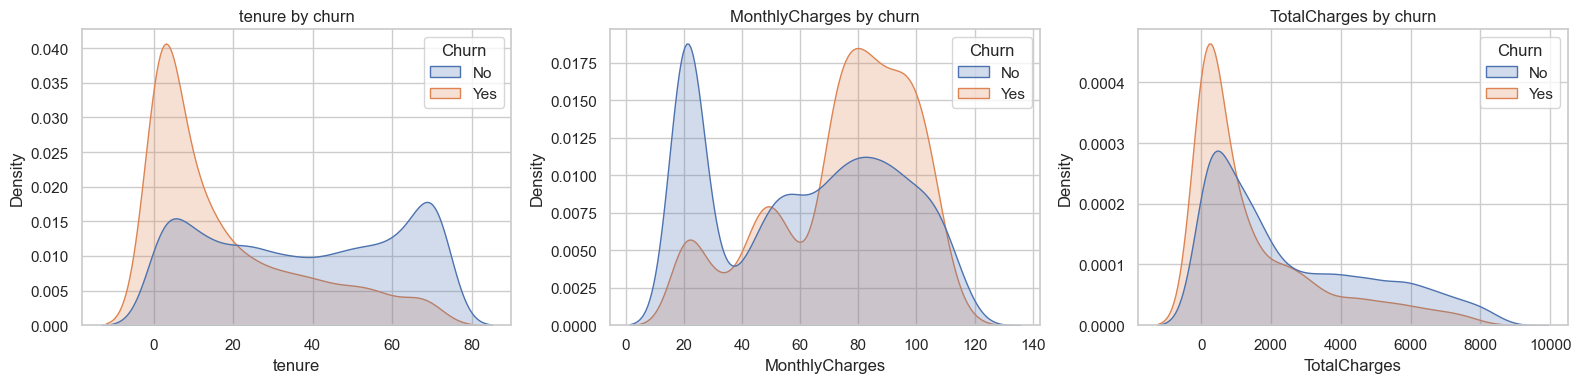

In [104]:
# 2. Numeric distributions split by churn (KDE overlay)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=data, x=col, hue="Churn", fill=True,
                common_norm=False, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()


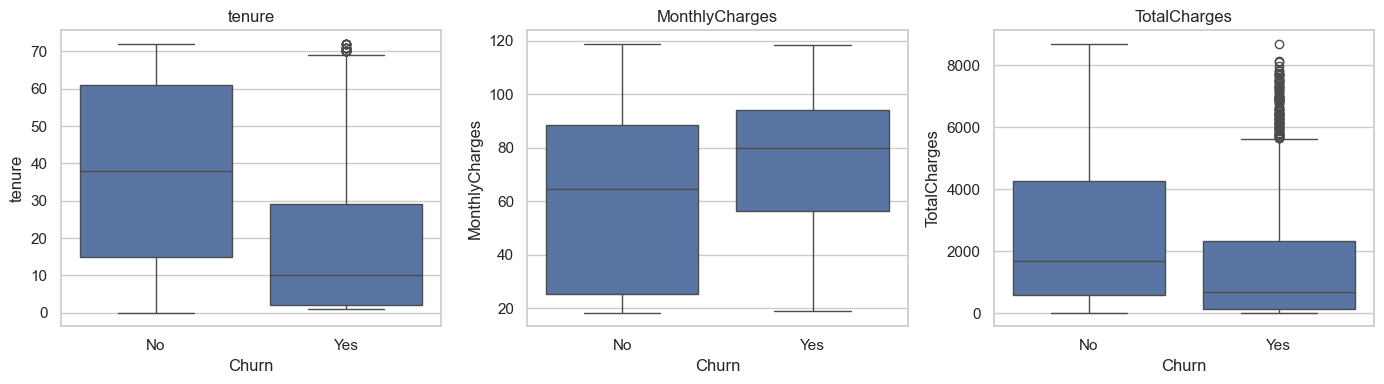

In [105]:
# 3. Box plots to see medians/outliers per churn group
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=data, x="Churn", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


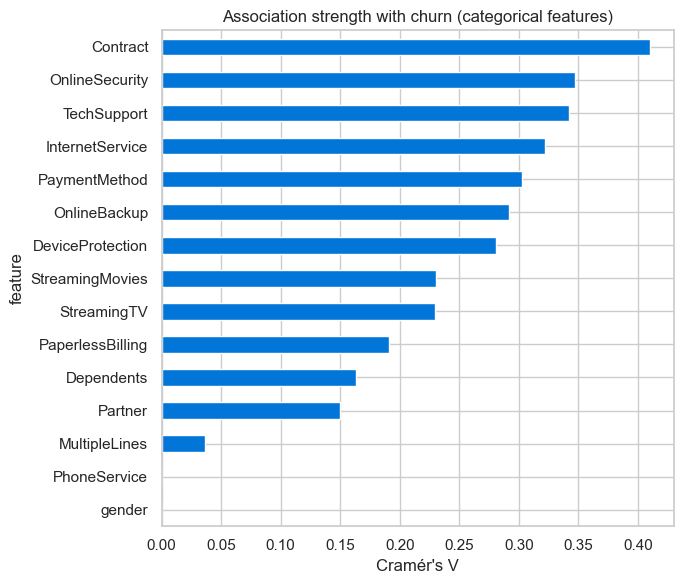

In [106]:
# 4. Cramér's V ranking as a horizontal bar (turns the stats table into a visual)
ax = chi2_results.set_index("feature")["cramers_v"].sort_values().plot(
    kind="barh", figsize=(7, 6), color="#0275d8")
ax.set_xlabel("Cramér's V")
ax.set_title("Association strength with churn (categorical features)")
plt.tight_layout()
plt.show()


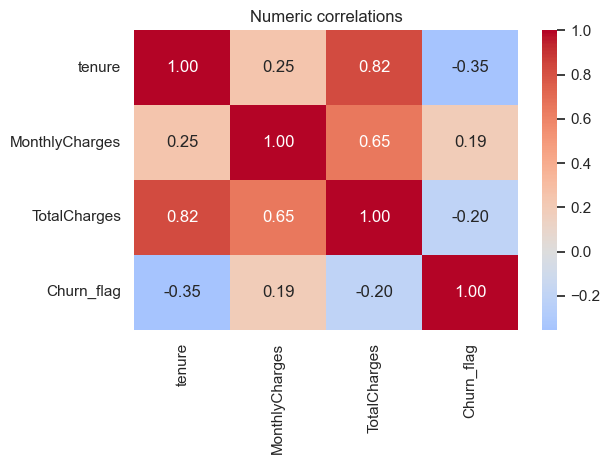

In [107]:
# 5. Correlation heatmap for numeric features + churn flag
corr = data[num_cols + ["Churn_flag"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Numeric correlations")
plt.tight_layout()
plt.show()


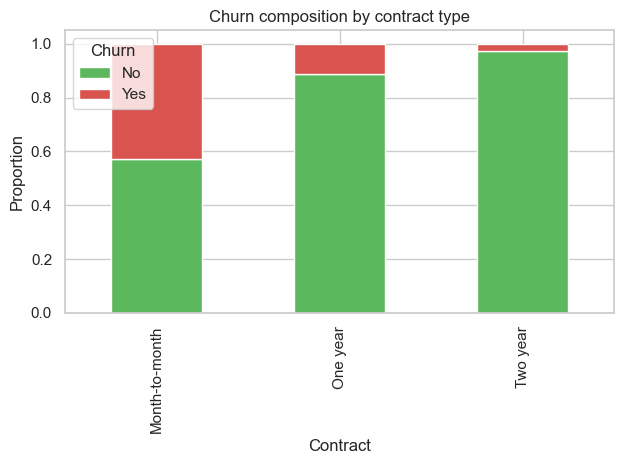

In [108]:
# 6. Stacked proportion bars: churn composition within a category
ct = pd.crosstab(data["Contract"], data["Churn"], normalize="index")
ct.plot(kind="bar", stacked=True, color=["#5cb85c", "#d9534f"])
plt.ylabel("Proportion")
plt.title("Churn composition by contract type")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()
